In [ ]:
pip install --upgrade keras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 17.4 MB/s eta 0:00:00
  Attempting uninstall: keras
    Found existing installation: keras 3.13.2
    Uninstalling keras-3.13.2:
      Successfully uninstalled keras-3.13.2


In [ ]:
pip install medmnist

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 3.5 MB/s eta 0:00:00


In [ ]:
pip install PyWavelets

In [ ]:
# importing libraries
import numpy as np
import tensorflow as tf
import random
import keras
import cv2
import os
import pywt
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
import matplotlib.image as img
import random as python_random

from tensorflow import keras
from tensorflow.keras import layers
from scipy.stats import skew, kurtosis, entropy
from skimage.io import imread
from skimage.transform import resize
from skimage.feature import hog
from skimage import exposure
from sklearn.metrics import confusion_matrix,accuracy_score, precision_score, recall_score, f1_score
from keras.metrics import Precision, Recall
from sklearn.decomposition import PCA
from keras import models
from matplotlib import offsetbox
from keras.layers import BatchNormalization
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D
from keras.layers import Activation, Dropout, Flatten, Dense, SpatialDropout3D
from keras import backend as K
from keras import layers
from keras.layers import Input, Dense, Conv2D, MaxPooling2D, UpSampling2D, Conv2DTranspose, Flatten, Reshape
from keras.models import Sequential, Model
from keras.layers import Flatten, Dense, Concatenate, Dot, Lambda, Input
from sklearn.manifold import TSNE
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense,GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential

np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
from medmnist.dataset import TissueMNIST #OrganCMNIST  #OrganSMNIST  #TissueMNIST
train_dataset = TissueMNIST (split="train", download=True)     #,size=128 )
test_dataset = TissueMNIST (split="test", download=True)
val_dataset = TissueMNIST(split="val", download=True)

100%|██████████| 125M/125M [00:27<00:00, 4.50MB/s]


In [ ]:
print(train_dataset)

Dataset TissueMNIST of size 28 (tissuemnist)
    Number of datapoints: 165466
    Root location: /root/.medmnist
    Split: train
    Task: multi-class
    Number of channels: 1
    Meaning of labels: {'0': 'Collecting Duct, Connecting Tubule', '1': 'Distal Convoluted Tubule', '2': 'Glomerular endothelial cells', '3': 'Interstitial endothelial cells', '4': 'Leukocytes', '5': 'Podocytes', '6': 'Proximal Tubule Segments', '7': 'Thick Ascending Limb'}
    Number of samples: {'train': 165466, 'val': 23640, 'test': 47280}
    Description: We use the BBBC051, available from the Broad Bioimage Benchmark Collection. The dataset contains 236,386 human kidney cortex cells, segmented from 3 reference tissue specimens and organized into 8 categories. We split the source dataset with a ratio of 7:1:2 into training, validation and test set. Each gray-scale image is 32×32×7 pixels, where 7 denotes 7 slices. We take maximum values across the slices and resize them into 28×28 gray-scale images.
    Lic

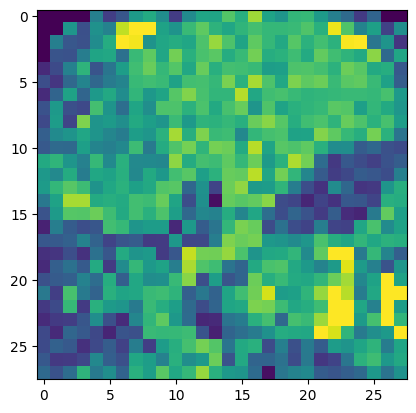

In [ ]:
plt.imshow(train_dataset.imgs[0])
plt.show()

In [ ]:
X_train=train_dataset.imgs
X_test=test_dataset.imgs
X_val=val_dataset.imgs

y_train=train_dataset.labels
y_test=test_dataset.labels
y_val=val_dataset.labels

In [ ]:
# # Normalization
X_train = X_train.astype('float32') / 255
X_test = X_test.astype('float32') / 255
X_val = X_val.astype('float32') / 255
y_train = y_train.astype('uint8')
y_test = y_test.astype('uint8')

**WADeX METHOD**

In [ ]:
WA_images_train = np.zeros((train_dataset.imgs.shape[0],14,14))
WA_images_test = np.zeros((test_dataset.imgs.shape[0],14,14))
WA_images_val = np.zeros((val_dataset.imgs.shape[0],14,14))

WH_images_train = np.zeros((train_dataset.imgs.shape[0],14,14))
WH_images_test = np.zeros((test_dataset.imgs.shape[0],14,14))
WH_images_val = np.zeros((val_dataset.imgs.shape[0],14,14))

WV_images_train = np.zeros((train_dataset.imgs.shape[0],14,14))
WV_images_test = np.zeros((test_dataset.imgs.shape[0],14,14))
WV_images_val = np.zeros((val_dataset.imgs.shape[0],14,14))

WD_images_train = np.zeros((train_dataset.imgs.shape[0],14,14))
WD_images_test = np.zeros((test_dataset.imgs.shape[0],14,14))
WD_images_val = np.zeros((val_dataset.imgs.shape[0],14,14))

In [ ]:
for indx in range(WA_images_train.shape[0]):
    coef_train = pywt.wavedec2(train_dataset.imgs[indx],'haar',level=1)
    WA_images_train[indx,:,:]= coef_train[0]

for indx in range(WH_images_train.shape[0]):
    coef_train = pywt.wavedec2(train_dataset.imgs[indx],'haar',level=1)
    WH_images_train[indx,:,:]= coef_train[1][0]

for indx in range(WV_images_train.shape[0]):
    coef_train = pywt.wavedec2(train_dataset.imgs[indx],'haar',level=1)
    WV_images_train[indx,:,:]= coef_train[1][1]

for indx in range(WD_images_train.shape[0]):
    coef_train = pywt.wavedec2(train_dataset.imgs[indx],'haar',level=1)
    WD_images_train[indx,:,:]= coef_train[1][2]

In [ ]:
for indx in range(WA_images_test.shape[0]):
    coef_test = pywt.wavedec2(test_dataset.imgs[indx],'haar',level=1)
    WA_images_test[indx,:,:]= coef_test[0]

for indx in range(WH_images_test.shape[0]):
    coef_test = pywt.wavedec2(test_dataset.imgs[indx],'haar',level=1)
    WH_images_test[indx,:,:]= coef_test[1][0]

for indx in range(WV_images_test.shape[0]):
    coef_test = pywt.wavedec2(test_dataset.imgs[indx],'haar',level=1)
    WV_images_test[indx,:,:]= coef_test[1][1]

for indx in range(WD_images_test.shape[0]):
    coef_test = pywt.wavedec2(test_dataset.imgs[indx],'haar',level=1)
    WD_images_test[indx,:,:]= coef_test[1][2]

In [ ]:
for indx in range(WA_images_val.shape[0]):
    coef_val = pywt.wavedec2(val_dataset.imgs[indx],'haar',level=1)
    WA_images_val[indx,:,:]= coef_val[0]

for indx in range(WH_images_val.shape[0]):
    coef_val = pywt.wavedec2(val_dataset.imgs[indx],'haar',level=1)
    WH_images_val[indx,:,:]= coef_val[1][0]

for indx in range(WV_images_val.shape[0]):
    coef_val = pywt.wavedec2(val_dataset.imgs[indx],'haar',level=1)
    WV_images_val[indx,:,:]= coef_val[1][1]

for indx in range(WD_images_val.shape[0]):
    coef_val = pywt.wavedec2(val_dataset.imgs[indx],'haar',level=1)
    WD_images_val[indx,:,:]= coef_val[1][2]

In [ ]:
#Average gradient
from scipy import ndimage, datasets
M=N=14

img_D = WD_images_train
grad_xD=cv2.Sobel(img_D,cv2.CV_64F,1,0,ksize=3)
grad_yD=cv2.Sobel(img_D,cv2.CV_64F,0,1,ksize=3)
grad_mag_D=np.hypot(grad_xD,grad_yD)
avg_grad_D=np.mean(grad_mag_D)/((M-1)*(N-1))
print(f'avg_grad_D(train): {avg_grad_D}')


img_V = WV_images_train
grad_xV=ndimage.prewitt(img_V, axis=0)
grad_yV=ndimage.prewitt(img_V, axis=1)
grad_mag_V=np.hypot(grad_xV,grad_yV)
avg_grad_V=np.mean(grad_mag_V)/((M-1)*(N-1))
print(f'avg_grad_V(train): {avg_grad_V}')

img_H = WH_images_train
grad_xH=ndimage.prewitt(img_H, axis=0)
grad_yH=ndimage.prewitt(img_H, axis=1)
grad_mag_H=np.hypot(grad_xH,grad_yH)
avg_grad_H=np.mean(grad_mag_H)/((M-1)*(N-1))
print(f'avg_grad_H(train): {avg_grad_H}')

avg_grad_D(train): 0.05354073753461688
avg_grad_V(train): 0.15876783068432454
avg_grad_H(train): 1.2707439248077765


In [ ]:
sum_grad_VHD=avg_grad_V+avg_grad_H+avg_grad_D
print(f'sum_grad_VHD(train):{sum_grad_VHD}')
# weight factors
lambda_V=1+(avg_grad_V/sum_grad_VHD)
print(f'lambda_V(train):{lambda_V}')

lambda_H=1+(avg_grad_H/sum_grad_VHD)
print(f'lambda_H(train):{lambda_H}')

lambda_D=1+(avg_grad_D/sum_grad_VHD)
print(f'lambda_D(train):{lambda_D}')

sum_grad_VHD(train):1.483052493026718
lambda_V(train):1.1070547613323518
lambda_H(train):1.85684352427361
lambda_D(train):1.036101714394038


In [ ]:
lambda_Vn=lambda_V/4
lambda_Hn=lambda_H/4
lambda_Dn=lambda_D/4

print(f'lambda_Vn(train):{lambda_Vn}')
print(f'lambda_Hn(train):{lambda_Hn}')
print(f'lambda_Dn(train):{lambda_Dn}')

lambda_Vn(train):0.27676369033308795
lambda_Hn(train):0.4642108810684025
lambda_Dn(train):0.2590254285985095


In [ ]:
from scipy import ndimage, datasets
M=N=14
img_VV = WV_images_test
grad_xVV=ndimage.prewitt(img_VV, axis=0)
grad_yVV=ndimage.prewitt(img_VV, axis=1)
grad_mag_VV=np.hypot(grad_xVV,grad_yVV)
avg_grad_VV=np.mean(grad_mag_VV)/((M-1)*(N-1))
print(f'avg_grad_V(test): {avg_grad_VV}')

img_HH = WH_images_test
grad_xHH=ndimage.prewitt(img_HH, axis=0)
grad_yHH=ndimage.prewitt(img_HH, axis=1)
grad_mag_HH=np.hypot(grad_xHH,grad_yHH)
avg_grad_HH=np.mean(grad_mag_HH)/((M-1)*(N-1))
print(f'avg_grad_H(test): {avg_grad_HH}')

img_DD = WD_images_test
grad_xDD=cv2.Sobel(img_DD,cv2.CV_64F,1,0,ksize=3)
grad_yDD=cv2.Sobel(img_DD,cv2.CV_64F,0,1,ksize=3)
grad_mag_DD=np.hypot(grad_xDD,grad_yDD)
avg_grad_DD=np.mean(grad_mag_DD)/((M-1)*(N-1))
print(f'avg_grad_D(test): {avg_grad_DD}')

avg_grad_V(test): 0.12786561428998494
avg_grad_H(test): 1.4936491087743302
avg_grad_D(test): 0.043087258243529644


In [ ]:
sum_grad_VVHHDD=avg_grad_VV+avg_grad_HH+avg_grad_DD
print(f'sum_grad_VHD(test):{sum_grad_VVHHDD}')
# weight factors
lambda_VV=1+(avg_grad_VV/sum_grad_VVHHDD)
print(f'lambda_V(test):{lambda_VV}')

lambda_HH=1+(avg_grad_HH/sum_grad_VVHHDD)
print(f'lambda_H(test):{lambda_HH}')

lambda_DD=1+(avg_grad_DD/sum_grad_VVHHDD)
print(f'lambda_D(test):{lambda_DD}')

sum_grad_VHD(test):1.6646019813078448
lambda_V(test):1.0768145272718728
lambda_H(test):1.8973010518711506
lambda_D(test):1.0258844208569768


In [ ]:
lambda_VVn=lambda_VV/4
lambda_HHn=lambda_HH/4
lambda_DDn=lambda_DD/4

In [ ]:
print(f'lambda_Vn(test):{lambda_VVn}')
print(f'lambda_Hn(test):{lambda_HHn}')
print(f'lambda_Dn(test):{lambda_DDn}')

lambda_Vn(test):0.2692036318179682
lambda_Hn(test):0.47432526296778765
lambda_Dn(test):0.2564711052142442


In [ ]:
img_DDD = WD_images_val
grad_xDDD=cv2.Sobel(img_DDD,cv2.CV_64F,1,0,ksize=3)
grad_yDDD=cv2.Sobel(img_DDD,cv2.CV_64F,0,1,ksize=3)
grad_mag_DDD=np.hypot(grad_xDDD,grad_yDDD)
avg_grad_DDD=np.mean(grad_mag_DDD)/((M-1)*(N-1))
print(f'avg_grad_D(val): {avg_grad_DDD}')


img_VVV = WV_images_val
grad_xVVV=ndimage.prewitt(img_VVV, axis=0)
grad_yVVV=ndimage.prewitt(img_VVV, axis=1)
grad_mag_VVV=np.hypot(grad_xVVV,grad_yVVV)
avg_grad_VVV=np.mean(grad_mag_VVV)/((M-1)*(N-1))
print(f'avg_grad_V(val): {avg_grad_VVV}')

img_HHH = WH_images_val
grad_xHHH=ndimage.prewitt(img_HHH, axis=0)
grad_yHHH=ndimage.prewitt(img_HHH, axis=1)
grad_mag_HHH=np.hypot(grad_xHHH,grad_yHHH)
avg_grad_HHH=np.mean(grad_mag_HHH)/((M-1)*(N-1))
print(f'avg_grad_H(val): {avg_grad_HHH}')

avg_grad_D(val): 0.053142409971842025
avg_grad_V(val): 0.1573721887410663
avg_grad_H(val): 1.2652513336049385


In [ ]:
sum_grad_VVVHHHDDD=avg_grad_VVV+avg_grad_HHH+avg_grad_DDD
print(f'sum_grad_VHD(val):{sum_grad_VVVHHHDDD}')
# weight factors
lambda_VVV=1+(avg_grad_VVV/sum_grad_VVVHHHDDD)
print(f'lambda_V(val):{lambda_VVV}')

lambda_HHH=1+(avg_grad_HHH/sum_grad_VVVHHHDDD)
print(f'lambda_H(val):{lambda_HHH}')

lambda_DDD=1+(avg_grad_DDD/sum_grad_VVVHHHDDD)
print(f'lambda_D(val):{lambda_DDD}')

sum_grad_VHD(val):1.475765932317847
lambda_V(val):1.1066376349357085
lambda_H(val):1.8573523117027961
lambda_D(val):1.0360100533614949


In [ ]:
lambda_VVVn=lambda_VVV/4
lambda_HHHn=lambda_HHH/4
lambda_DDDn=lambda_DDD/4

In [ ]:
print(f'lambda_Vn(val):{lambda_VVVn}')
print(f'lambda_Hn(val):{lambda_HHHn}')
print(f'lambda_Dn(val):{lambda_DDDn}')

lambda_Vn(val):0.27665940873392714
lambda_Hn(val):0.46433807792569903
lambda_Dn(val):0.2590025133403737


In [ ]:
train_stack = np.zeros((train_dataset.imgs.shape[0],14,14,4))
for i in range (train_dataset.imgs.shape[0]):
   img=np.dstack((WA_images_train[i],lambda_Vn*WV_images_train[i],lambda_Hn*WH_images_train[i],lambda_Dn*WD_images_train[i]))

  #  img=np.dstack((WA_images_train[i],WV_images_train[i],WH_images_train[i],WD_images_train[i]))
   train_stack[i,:,:]=img

In [ ]:
test_stack = np.zeros((test_dataset.imgs.shape[0],14,14,4))
for i in range (test_dataset.imgs.shape[0]):
   img=np.dstack((WA_images_test[i],lambda_VVn*WV_images_test[i],lambda_HHn*WH_images_test[i],lambda_DDn*WD_images_test[i] ))

  #  img=np.dstack((WA_images_test[i],WV_images_test[i],WH_images_test[i],WD_images_test[i] ))
   test_stack[i,:,:]=img

In [ ]:
val_stack = np.zeros((val_dataset.imgs.shape[0],14,14,4))
for i in range (val_dataset.imgs.shape[0]):
   img=np.dstack((WA_images_val[i],lambda_VVVn*WV_images_val[i],lambda_HHHn*WH_images_val[i],lambda_DDDn*WD_images_val[i] ))

  #  img=np.dstack((WA_images_test[i],WV_images_test[i],WH_images_test[i],WD_images_test[i] ))
   val_stack[i,:,:]=img

In [ ]:
X_train_s=train_stack
X_test_s=test_stack
X_val_s=val_stack

In [ ]:
# Initialize empty list to store single-channel images
single_channel_images_train = []

# Apply channel attention mechanism to each image
for image in X_train_s:
    # Compute channel attention weights
    attention_weights = np.mean(image, axis=(0, 1))

    # Normalize attention weights
    attention_weights = attention_weights / np.sum(attention_weights)

    # Apply attention weights to channels
    single_channel_image_train = np.sum(image * attention_weights, axis=2)

    # Reshape to original image shape
    # single_channel_image_train = single_channel_image_train.reshape(28, 28)

    # Append single-channel image to list
    single_channel_images_train.append(single_channel_image_train)

# Convert list to numpy array
single_channel_images_train = np.array(single_channel_images_train)

In [ ]:
# Initialize empty list to store single-channel images
single_channel_images_test = []

# Apply channel attention mechanism to each image
for image in X_test_s:
    # Compute channel attention weights
    attention_weights = np.mean(image, axis=(0, 1))

    # Normalize attention weights
    attention_weights = attention_weights / np.sum(attention_weights)

    # Apply attention weights to channels
    single_channel_image_test = np.sum(image * attention_weights, axis=2)

    # Reshape to original image shape
    # single_channel_image_train = single_channel_image_train.reshape(28, 28)

    # Append single-channel image to list
    single_channel_images_test.append(single_channel_image_test)

# Convert list to numpy array
single_channel_images_test = np.array(single_channel_images_test)

In [ ]:
# Initialize empty list to store single-channel images
single_channel_images_val = []

# Apply channel attention mechanism to each image
for image in X_val_s:
    # Compute channel attention weights
    attention_weights = np.mean(image, axis=(0, 1))

    # Normalize attention weights
    attention_weights = attention_weights / np.sum(attention_weights)

    # Apply attention weights to channels
    single_channel_image_val = np.sum(image * attention_weights, axis=2)

    # Reshape to original image shape
    # single_channel_image_train = single_channel_image_train.reshape(28, 28)

    # Append single-channel image to list
    single_channel_images_val.append(single_channel_image_val)

# Convert list to numpy array
single_channel_images_val = np.array(single_channel_images_val)

In [ ]:
X_train=single_channel_images_train
X_test=single_channel_images_test
X_val=single_channel_images_val

**Making pairs**

In [ ]:
import numpy as np

def generate_pairs(octmnist_images, octmnist_labels):
    # Initialize lists to store pairs and labels
    pairs = []
    labels = []

    # Loop until batch size is reached
    while len(pairs) < len(octmnist_images):
        # Randomly select anchor image
        idx1 = np.random.randint(0, len(octmnist_images))
        anchor_img = octmnist_images[idx1]
        anchor_label = octmnist_labels[idx1]

        # Generate positive pair
        idx2 = np.random.randint(0, len(octmnist_images))
        while octmnist_labels[idx2] != anchor_label:
            idx2 = np.random.randint(0, len(octmnist_images))
        positive_img = octmnist_images[idx2]

        # Generate negative pair
        idx3 = np.random.randint(0, len(octmnist_images))
        while octmnist_labels[idx3] == anchor_label:
            idx3 = np.random.randint(0, len(octmnist_images))
        negative_img = octmnist_images[idx3]

        # Append pairs and labels
        pairs.append((anchor_img, positive_img))
        labels.append(1)  # Positive pair label
        pairs.append((anchor_img, negative_img))
        labels.append(0)  # Negative pair label

    return np.array(pairs), np.array(labels)

#make pairs for train,test,validation sets
pairs_train, labels_train = generate_pairs(X_train, y_train)
pairs_test, labels_test = generate_pairs(X_test, y_test)
pairs_val, labels_val = generate_pairs(X_val, y_val)

In [ ]:
print(pairs_train.shape)
print(pairs_test.shape)
print(pairs_val.shape)

(165466, 2, 28, 28)
(47280, 2, 28, 28)
(23640, 2, 28, 28)


**Loss function/distance/SNN architecture**

In [ ]:
import keras
from keras import ops
def loss(margin=1):
    """Provides 'contrastive_loss' an enclosing scope with variable 'margin'.

    Arguments:
        margin: Integer, defines the baseline for distance for which pairs
                should be classified as dissimilar. - (default is 1).

    Returns:
        'contrastive_loss' function with data ('margin') attached.
    """

    # Contrastive loss = mean( (1-true_value) * square(prediction) +
    #                         true_value * square( max(margin-prediction, 0) ))
    def contrastive_loss(y_true, y_pred):
        """Calculates the contrastive loss.

        Arguments:
            y_true: List of labels, each label is of type float32.
            y_pred: List of predictions of same length as of y_true,
                    each label is of type float32.

        Returns:
            A tensor containing contrastive loss as floating point value.
        """

        square_pred = ops.square(y_pred)
        margin_square = ops.square(ops.maximum(margin - (y_pred), 0))
        return ops.mean((1 - y_true) * square_pred + (y_true) * margin_square)

    return contrastive_loss

In [ ]:
def euclidean_distance(vects):
    """Find the Euclidean distance between two vectors.

    Arguments:
        vects: List containing two tensors of same length.

    Returns:
        Tensor containing euclidean distance
        (as floating point value) between vectors.
    """

    x, y = vects
    sum_square = tf.math.reduce_sum(tf.math.square(x - y), axis=1, keepdims=True)
    return tf.math.sqrt(tf.math.maximum(sum_square, tf.keras.backend.epsilon()))

In [ ]:
#SNN architecture
input_shape=(28,28,1)     # for WADeX (14,14,1)    # for original (28,28,1)
left_input = Input(input_shape)
right_input = Input(input_shape)

model = keras.models.Sequential([
    keras.layers.Conv2D(16, (3,3), activation='relu',input_shape=input_shape, padding='same',name='conv2d_1'),  #input in previous archi for paper
    keras.layers.MaxPooling2D((2, 2), padding='same'),
    keras.layers.Conv2D(8, (3,3), activation='relu', padding='same',name='conv2d_2'),
    keras.layers.MaxPooling2D((2,2), padding='same'),
    keras.layers.Conv2D(8, (3,3), activation='relu', padding='same',name='conv2d_3'),
    keras.layers.MaxPooling2D((2,2), padding='same'),
    keras.layers.Flatten(),
  ])

encoded_l = model(left_input)
encoded_r = model(right_input)

subtracted = keras.layers.Lambda(euclidean_distance) ([encoded_l, encoded_r])
normal_layer = keras.layers.BatchNormalization()(subtracted)
prediction = Dense(1, activation='sigmoid')(normal_layer)
siamese_net = Model(inputs=[left_input, right_input], outputs=prediction)

optimizer= tf.keras.optimizers.Adam(learning_rate=0.01)
siamese_net.compile(loss=loss(margin=1), optimizer=optimizer, metrics=["accuracy"])   #loss='binary_crossentropy'loss(margin=1)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
history= siamese_net.fit([pairs_train[:,0], pairs_train[:,1]], labels_train[:], validation_data=([pairs_val[:,0], pairs_val[:,1]], labels_val[:]), epochs=10)

Epoch 1/10
5171/5171 ━━━━━━━━━━━━━━━━━━━━ 198s 38ms/step - accuracy: 0.5538 - loss: 0.2458 - val_accuracy: 0.5599 - val_loss: 0.2436
Epoch 2/10
5171/5171 ━━━━━━━━━━━━━━━━━━━━ 194s 36ms/step - accuracy: 0.5597 - loss: 0.2442 - val_accuracy: 0.5573 - val_loss: 0.2433
Epoch 3/10
5171/5171 ━━━━━━━━━━━━━━━━━━━━ 177s 34ms/step - accuracy: 0.5610 - loss: 0.2439 - val_accuracy: 0.5593 - val_loss: 0.2430
Epoch 4/10
5171/5171 ━━━━━━━━━━━━━━━━━━━━ 197s 38ms/step - accuracy: 0.5621 - loss: 0.2438 - val_accuracy: 0.5611 - val_loss: 0.2428
Epoch 5/10
5171/5171 ━━━━━━━━━━━━━━━━━━━━ 183s 35ms/step - accuracy: 0.5622 - loss: 0.2437 - val_accuracy: 0.5599 - val_loss: 0.2429
Epoch 6/10
5171/5171 ━━━━━━━━━━━━━━━━━━━━ 180s 35ms/step - accuracy: 0.5622 - loss: 0.2436 - val_accuracy: 0.5615 - val_loss: 0.2428
Epoch 7/10
5171/5171 ━━━━━━━━━━━━━━━━━━━━ 202s 35ms/step - accuracy: 0.5626 - loss: 0.2436 - val_accuracy: 0.5613 - val_loss: 0.2428
Epoch 8/10
5171/5171 ━━━━━━━━━━━━━━━━━━━━ 179s 35ms/step - accuracy: 

In [ ]:
# from tensorflow.keras.callbacks import EarlyStopping
# early_stopping = EarlyStopping(monitor='val_accuracy')
# history=siamese_net.fit([pairs_train[:,0], pairs_train[:,1]], labels_train[:], validation_data=([pairs_val[:,0], pairs_val[:,1]], labels_val[:]),epochs= 20,callbacks=[early_stopping])

**t-SNE Embeddings**

In [ ]:
embeddings= model.predict(X_test)

1478/1478 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step


In [ ]:
X_embedded = TSNE(n_components=2,random_state=10).fit_transform(embeddings)

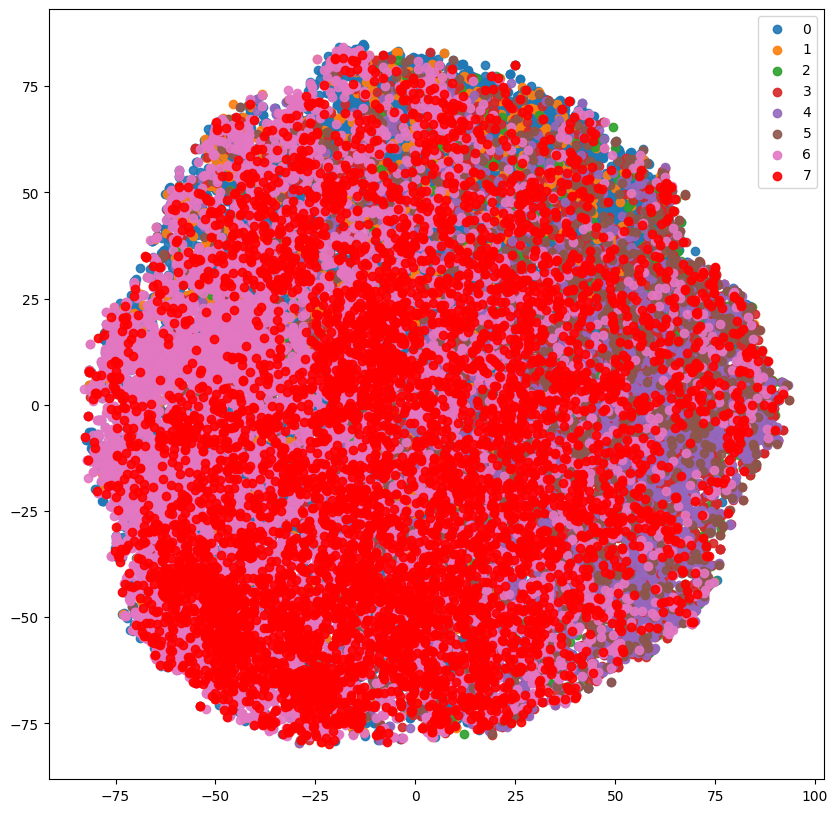

In [ ]:
classes = ['0', '1', '2', '3', '4', '5', '6', '7']#, '8', '9','10']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728',
               '#9467bd', '#8c564b', '#e377c2','red']#,'blue','orange','green']
plt.figure(figsize=(10,10))
for i in range(8):
    inds = np.where(y_test==i)[0]
    plt.scatter(X_embedded[inds,0], X_embedded[inds,1], alpha=0.9, color=colors[i])
plt.legend(classes)

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


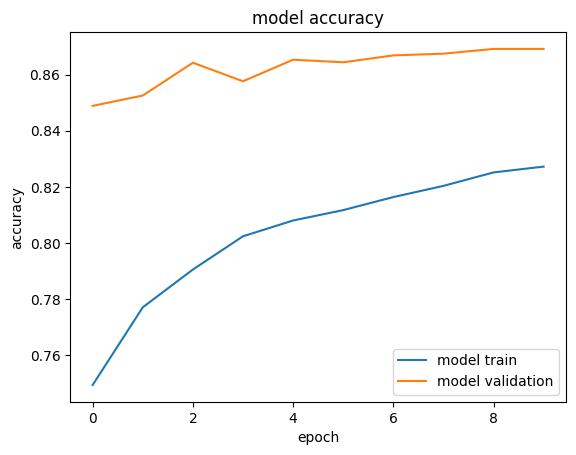

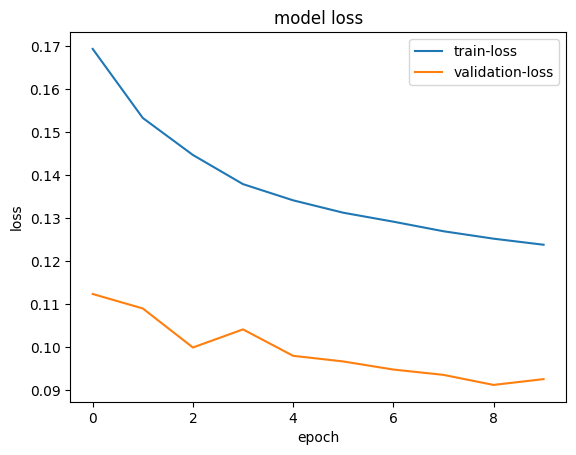

In [ ]:
#Plot the results
callbacks=[history]
print(history.history.keys())
# summarize history for accuracy
plt.plot(history.history['accuracy'])#, 'r-')
plt.plot(history.history['val_accuracy'])#,'g-+')
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
#plt.ylim([0.50, 0.66])
plt.legend(['model train', 'model validation', ], loc='lower right')
plt.show()
# summarize history for loss
plt.plot(history.history['loss'])#, 'ro-')
plt.plot(history.history['val_loss'])#, 'g-+')
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train-loss', 'validation-loss'], loc='upper right')
plt.show()

In [ ]:
# from sklearn.metrics import accuracy_score
accuracy =np.mean(history.history['accuracy'])
print(f'Training Accuracy: {accuracy}')

Training Accuracy: 0.8465048313140869


In [ ]:
# from sklearn.metrics import accuracy_score
loss =np.mean(history.history['loss'])
print(f'Training Loss: {loss}')

Training Loss: 0.10847087800502778


In [ ]:
accuracy_1 =np.mean(history.history['val_accuracy'])
print(f'validation Accuracy: {accuracy_1}')

validation Accuracy: 0.9010166347026825


In [ ]:
# from sklearn.metrics import accuracy_score
loss_1 =np.mean(history.history['val_loss'])
print(f'validation Loss: {loss_1}')

validation Loss: 0.07475126385688782


**SNN Prediction and pairs visualization**

In [ ]:
def visualize(pairs, labels, to_show=30, num_col=2, predictions=None, test=False):
    """Creates a plot of pairs and labels, and prediction if it's test dataset.

    Arguments:
        pairs: Numpy Array, of pairs to visualize, having shape
               (Number of pairs, 2, 28, 28).
        to_show: Int, number of examples to visualize (default is 6)
                `to_show` must be an integral multiple of `num_col`.
                 Otherwise it will be trimmed if it is greater than num_col,
                 and incremented if if it is less then num_col.
        num_col: Int, number of images in one row - (default is 3)
                 For test and train respectively, it should not exceed 3 and 7.
        predictions: Numpy Array of predictions with shape (to_show, 1) -
                     (default is None)
                     Must be passed when test=True.
        test: Boolean telling whether the dataset being visualized is
              train dataset or test dataset - (default False).

    Returns:
        None.
    """

    # Define num_row
    # If to_show % num_col != 0
    #    trim to_show,
    #       to trim to_show limit num_row to the point where
    #       to_show % num_col == 0
    #
    # If to_show//num_col == 0
    #    then it means num_col is greater then to_show
    #    increment to_show
    #       to increment to_show set num_row to 1
    num_row = to_show // num_col if to_show // num_col != 0 else 1

    # `to_show` must be an integral multiple of `num_col`
    #  we found num_row and we have num_col
    #  to increment or decrement to_show
    #  to make it integral multiple of `num_col`
    #  simply set it equal to num_row * num_col
    to_show = num_row * num_col

    # Plot the images
    fig, axes = plt.subplots(num_row, num_col, figsize=(5, 5))
    for i in range(to_show):

        # If the number of rows is 1, the axes array is one-dimensional
        if num_row == 1:
            ax = axes[i % num_col]
        else:
            ax = axes[i // num_col, i % num_col]

        ax.imshow(tf.concat([pairs[i][0], pairs[i][1]], axis=1))#, cmap="jet",interpolation='bicubic')
        ax.set_axis_off()
        if test:
            ax.set_title("True: {} | Pred: {:.5f}".format(labels[i], predictions[i][0]))
        else:
            ax.set_title("Label: {}".format(labels[i]))
    if test:
        plt.tight_layout(rect=(0, 0, 1.9, 1.9), w_pad=0.0)
    else:
        plt.tight_layout(rect=(0, 0, 1.5, 1.5))
    plt.show()

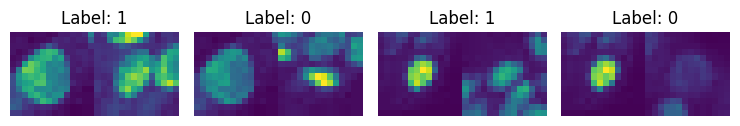

In [ ]:
visualize(pairs_train[:-1], labels_train[:-1], to_show=4, num_col=4)

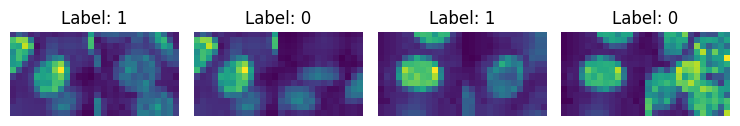

In [ ]:
visualize(pairs_test[:-1], labels_test[:-1], to_show=4, num_col=4)

739/739 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step


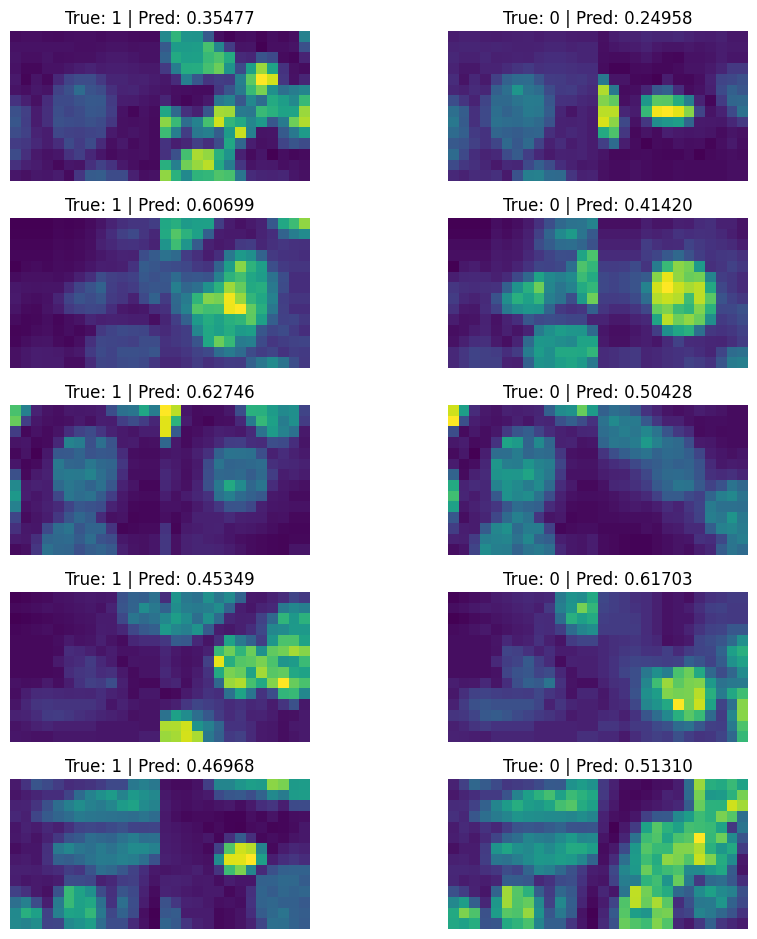

In [ ]:
predictions = siamese_net.predict([pairs_val[:, 0], pairs_val[:, 1]])
visualize(pairs_val, labels_val, to_show=10, predictions=predictions, test=True)

**Transparency (Precision,recall)**

In [ ]:
predictions = siamese_net.predict([pairs_test[:, 0], pairs_test[:, 1]])
accuracy = accuracy_score(labels_test, predictions.round())
precision = precision_score(labels_test, predictions.round(), average='weighted')
recall = recall_score(labels_test, predictions.round(), average='weighted')

print(f'Accuracy: {accuracy:.3f}')
print(f'Precision: {precision:.3f}')
print(f'Recall: {recall:.3f}')

1478/1478 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step
Accuracy: 0.563
Precision: 0.567
Recall: 0.563


In [ ]:
####IWT#####
# reconstructed_images = np.zeros((17778, 28, 28))  # assuming original image size is 28x28

# for i in range(17778):
#     coeffs = (single_channel_images_test[i, :, :, 0],  # LL
#               (single_channel_images_test[i, :, :, 1],  # LH
#                single_channel_images_test[i, :, :, 2],  # HL
#                single_channel_images_test[i, :, :, 3]))  # HH

#     reconstructed_image = pywt.idwt2(coeffs, 'haar')
#     reconstructed_images[i, :, :] = reconstructed_image

In [1]:
# plt.imshow(reconstructed_images[0])
# plt.show()